In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE, MultiDAE, loss_function, NDCG_binary_at_k_batch, Recall_at_k_batch
import datetime

In [2]:
%load_ext tensorboard

In [3]:
LOGS_BASE_PATH = os.path.join("logs")
def get_current_time():
    return datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [5]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

## Setup the dataset

In [6]:
df_matrix_mf = df.copy()
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf[["username", "id", "affinity"] + spoti.NUMERICAL_FEATURES]
df_matrix_mf["affinity"] *= 100

In [7]:
df_matrix_mf = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)

In [8]:
df_matrix_mf = df_matrix_mf.sample(frac=1)
df_matrix_mf

,id,username,danceability,duration_ms,instrumentalness,affinity
6774,Go civil vote,John Morgan,0.949873,0.862969,1.114799,1.097572
5459,Stop subject,Vicki Shannon,1.091987,0.974610,0.965433,1.033636
6736,Dream total,Kenneth Valdez,0.946347,0.775939,0.957249,0.829343
1439,Be although,Joseph Kirby,0.991692,0.943227,0.987548,1.024182
1815,Describe son,Steven Smith,0.950652,0.833363,1.016970,1.082873
...,...,...,...,...,...,...
7494,City song foot,Matthew Rollins,1.122796,1.029472,1.184110,1.018909
6091,Enter catch,Roy Peterson,1.092202,0.846976,1.162221,0.976818
6280,Enough crime,Cathy Barber,0.955755,0.912606,0.858916,0.970905
7332,Name say movie,Christopher Thomas,1.173876,0.913702,0.978481,0.986366


In [9]:
matrix_mf = MatrixDataset(df_matrix_mf, "username", "id", "affinity", device=device, dtype=dtype)
user_interacted_with = matrix_mf.R
user_interacted_with

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 1.1334, 1.0230,  ..., 0.9359, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
       device='mps:0')

In [10]:
user_interacted_with.shape

torch.Size([50, 4742])

In [11]:
alpha = matrix_mf.compute_alpha().item()
user_interacted_with *= alpha
alpha

30.665973663330078

In [12]:
n_users, n_items = user_interacted_with.shape

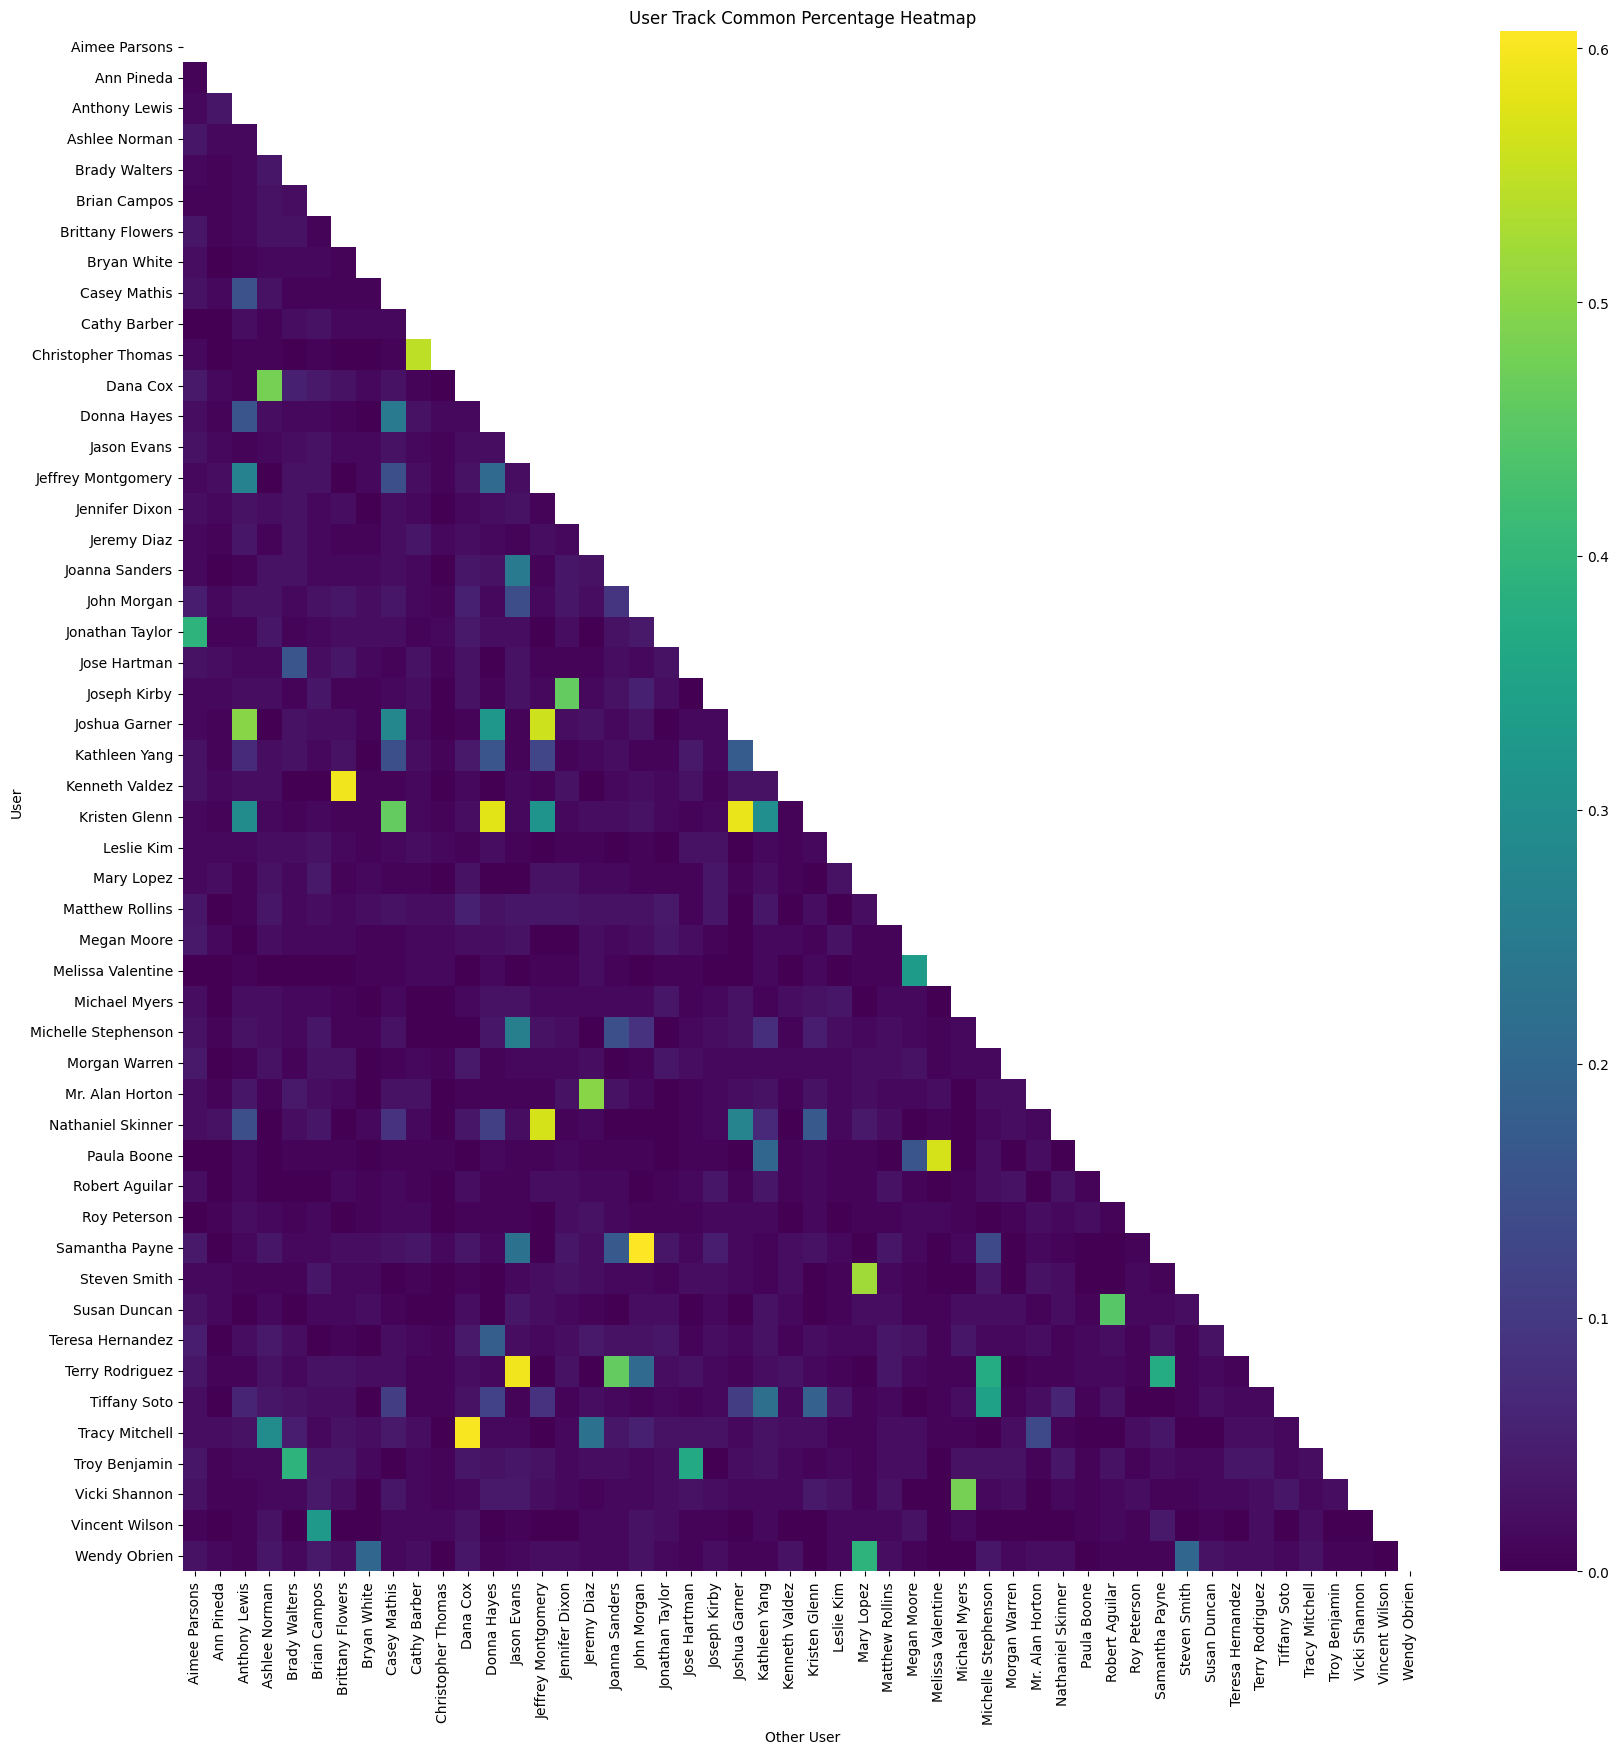

In [13]:
df_user_similarities = user_similarities.calculate_users_track_common_percentage(df_matrix_mf, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20))

# Define and train the MultiVAE model

In [14]:
user_interacted_with

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000, 34.7572, 31.3715,  ..., 28.6988,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       device='mps:0')

In [15]:
size = user_interacted_with.shape[0]
develop_percentage = 0.8
train_percentage = 1

develop_set = user_interacted_with[:int(size * develop_percentage)]
train_set = develop_set[:int(develop_set.shape[0] * train_percentage)]
validation_set = develop_set[int(develop_set.shape[0] * train_percentage):]
test_set = user_interacted_with[int(size * develop_percentage):]

train_dataset = TensorDataset(train_set)
validation_dataset = TensorDataset(validation_set)
test_dataset = TensorDataset(test_set)

print(f"Develop set shape: {develop_set.shape}")
print(f"Train set shape: {train_set.shape}")
print(f"Validation set shape: {validation_set.shape}")
print(f"Test set shape: {test_set.shape}")

Develop set shape: torch.Size([40, 4742])
Train set shape: torch.Size([40, 4742])
Validation set shape: torch.Size([0, 4742])
Test set shape: torch.Size([10, 4742])


In [16]:
p_dims = [200, 600, n_items]
model = MultiVAE(p_dims=p_dims).to(device=device, dtype=dtype)

In [17]:
batch_size = 32
anneal_cap = 0.2
total_anneal_steps = 200000

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
model.train_model(
    optimizer,
    train_loader,
    num_epochs=1000,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
    summary_writer=summary_writer
)

Epoch 1 Loss: 38988.837890625
Epoch 11 Loss: 36373.35546875
Epoch 21 Loss: 27625.541015625
Epoch 31 Loss: 24553.3291015625
Epoch 41 Loss: 23811.1533203125
Epoch 51 Loss: 23462.9677734375
Epoch 61 Loss: 23273.8037109375
Epoch 71 Loss: 23196.9287109375
Epoch 81 Loss: 23123.130859375
Epoch 91 Loss: 23095.0625
Epoch 101 Loss: 23066.259765625
Epoch 111 Loss: 23039.439453125
Epoch 121 Loss: 23028.6416015625
Epoch 131 Loss: 23022.9267578125
Epoch 141 Loss: 23008.908203125
Epoch 151 Loss: 22997.7841796875
Epoch 161 Loss: 23009.6474609375
Epoch 171 Loss: 22993.560546875
Epoch 181 Loss: 22990.5107421875
Epoch 191 Loss: 22983.1513671875
Epoch 201 Loss: 22982.203125
Epoch 211 Loss: 22975.1826171875
Epoch 221 Loss: 22977.1435546875
Epoch 231 Loss: 22975.185546875
Epoch 241 Loss: 22969.7939453125
Epoch 251 Loss: 22972.572265625
Epoch 261 Loss: 22970.650390625
Epoch 271 Loss: 22970.79296875
Epoch 281 Loss: 22965.77734375
Epoch 291 Loss: 22963.294921875
Epoch 301 Loss: 22965.4306640625
Epoch 311 Loss:

In [18]:
total_loss, n100_list, r20_list, r50_list = model.evaluate_model(
    training_set=train_set,
    test_set=test_set,
    batch_size=batch_size,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
    summary_writer=summary_writer
)
print(f"Total loss: {total_loss}")
print(f"n100_list: {n100_list}")
print(f"r20_list: {r20_list}")
print(f"r50_list: {r50_list}")

Total loss: 22947.431640625
n100_list: 0.28035120598920427
r20_list: 0.4
r50_list: 0.388


In [19]:
# retrieve users latent representations (mean and variance)
user_names = df_matrix_mf[:size * train_percentage]["username"].sort_values().unique().tolist()
user_names

['Aimee Parsons',
 'Bryan White',
 'Christopher Thomas',
 'Dana Cox',
 'Donna Hayes',
 'Jason Evans',
 'Jennifer Dixon',
 'Jeremy Diaz',
 'Joanna Sanders',
 'John Morgan',
 'Jonathan Taylor',
 'Jose Hartman',
 'Joseph Kirby',
 'Joshua Garner',
 'Kathleen Yang',
 'Kenneth Valdez',
 'Mary Lopez',
 'Megan Moore',
 'Melissa Valentine',
 'Michelle Stephenson',
 'Mr. Alan Horton',
 'Paula Boone',
 'Robert Aguilar',
 'Roy Peterson',
 'Steven Smith',
 'Teresa Hernandez',
 'Terry Rodriguez',
 'Tracy Mitchell',
 'Vicki Shannon']

In [20]:
model.eval()
with torch.no_grad():
    mu, logvar = model.encode(train_set)
    z = model.reparameterize(mu, logvar)
    z = z.cpu().numpy()
    mu = mu.cpu().numpy()
    std = np.exp(0.5 * logvar.cpu().numpy())
    logvar = logvar.cpu().numpy()

print(z.shape)
print(mu.shape)
print(logvar.shape)

(40, 200)
(40, 200)
(40, 200)


In [21]:
# Define the number of points for grid, the width of the gaussian curves and color map
# dim1 = range(0, p_dims[0])
# dim2 = range(0, p_dims[0])
dim1 = range(0, 5)
dim2 = range(0, 5)

# for i in dim1:
#     for j in dim2:
#         if i >= j:
#             continue
#         # # Plot 2D latent space using and add annotations with usernames
#         # fig = px.scatter(x=z[:, i], y=z[:, j], hover_name=usersnames, color=usersnames)
#         # fig.update_traces(marker=dict(size=10))
#         # fig.update_layout(title="2D Latent Space")
#         # # Show the usernames next to the points
#         # for i_username, username in enumerate(usersnames):
#         #     fig.add_annotation(
#         #         x=z[i_username, i], y=z[i_username, j], text=username, showarrow=False, xshift=-20, yshift=15
#         #     )
#         # fig.show()
        
#         # Using sns
#         fig, ax = plt.subplots(figsize=(10, 5))
#         sns.scatterplot(x=z[:, i], y=z[:, j], hue=usersnames, ax=ax)
#         for i_username, username in enumerate(usersnames):
#             ax.text(z[i_username, i], z[i_username, j] + 0.3, username, fontsize=8)
#         ax.set_title(f"2D Latent Space ({i}, {j})")
#         ax.set_xlabel(f"z{i}")
#         ax.set_ylabel(f"z{j}")
#         plt.show()

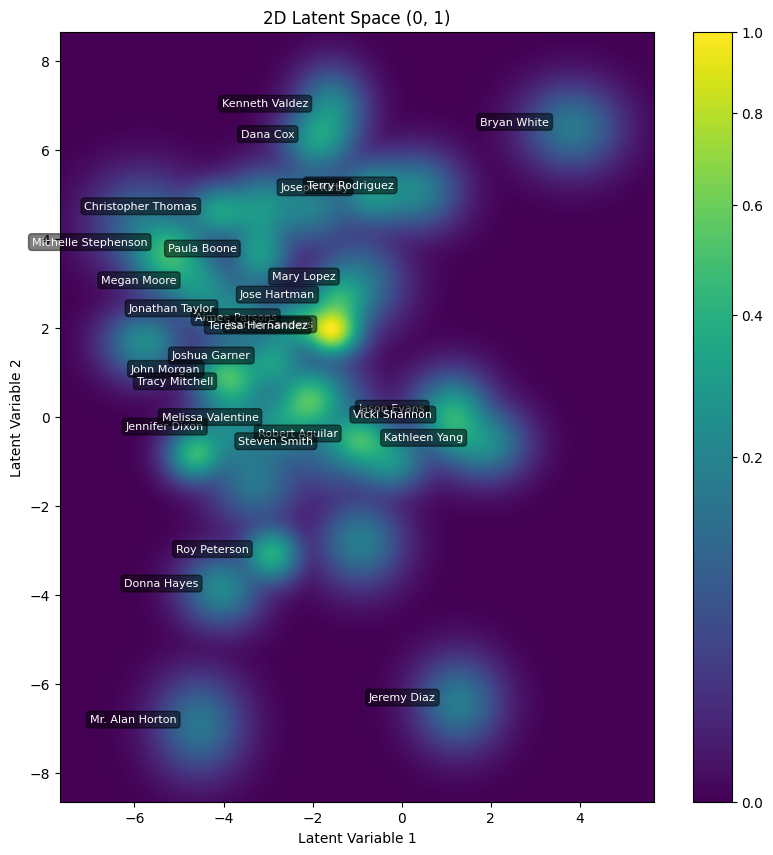

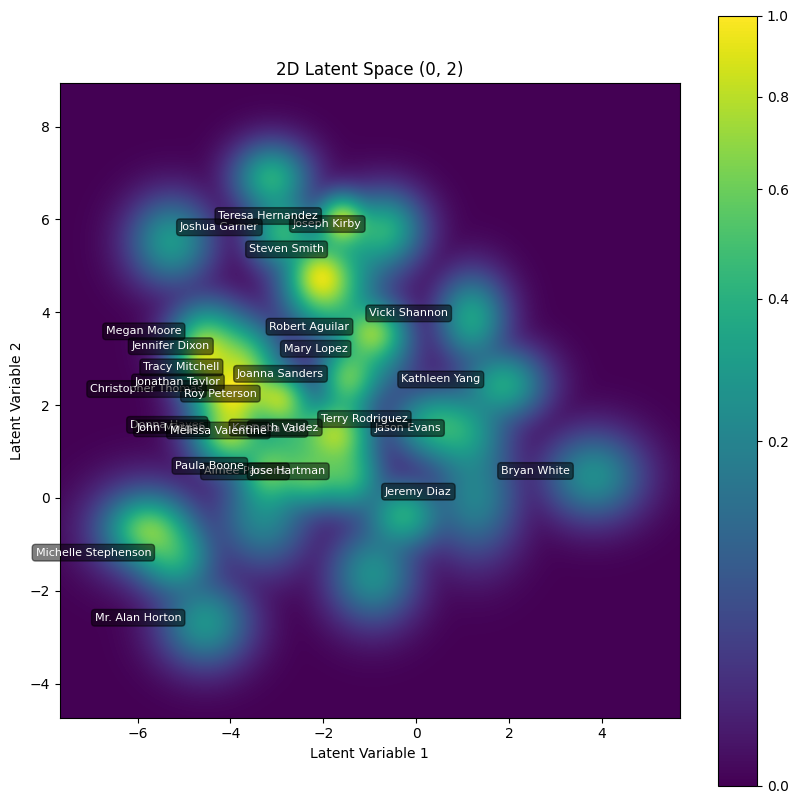

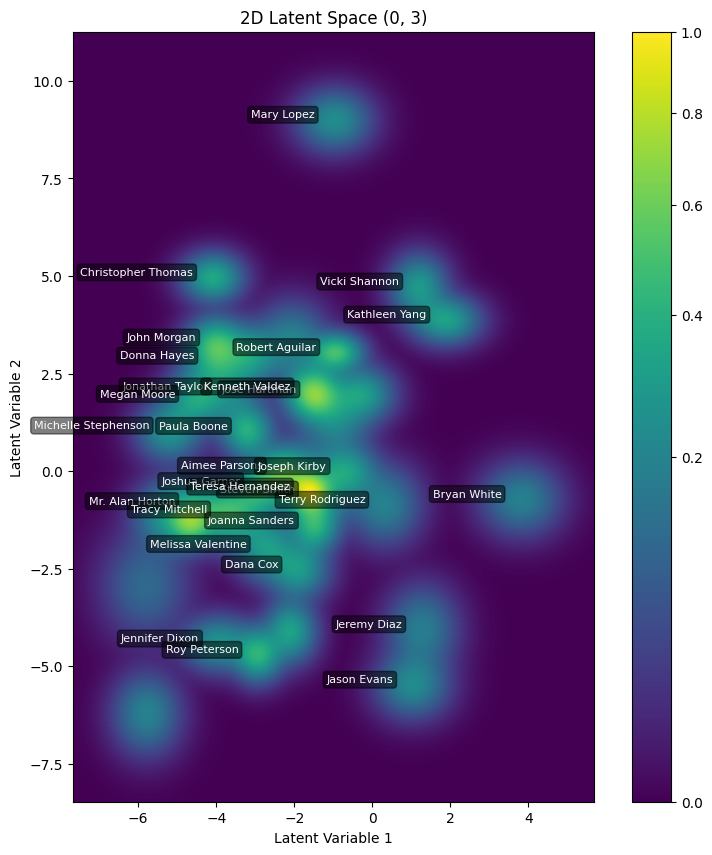

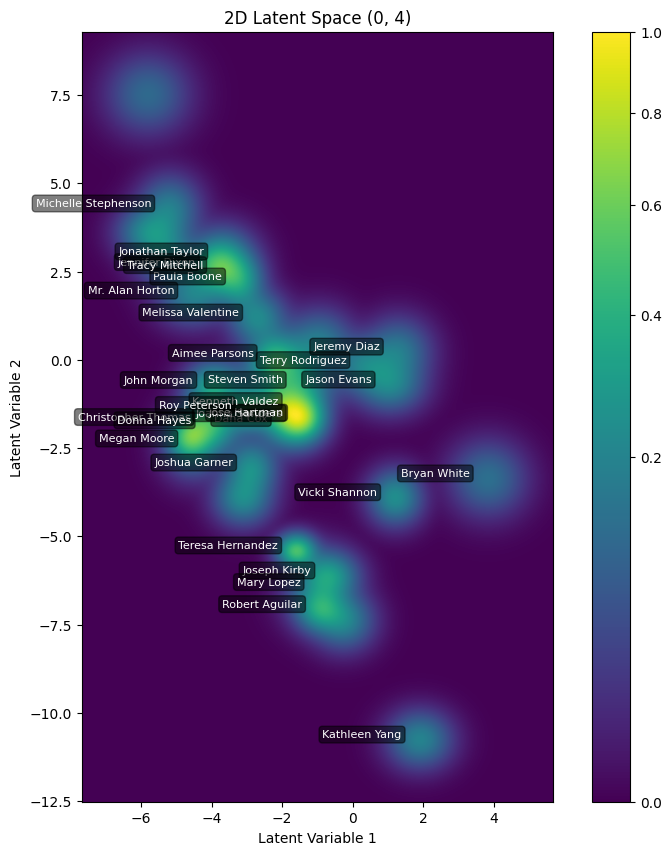

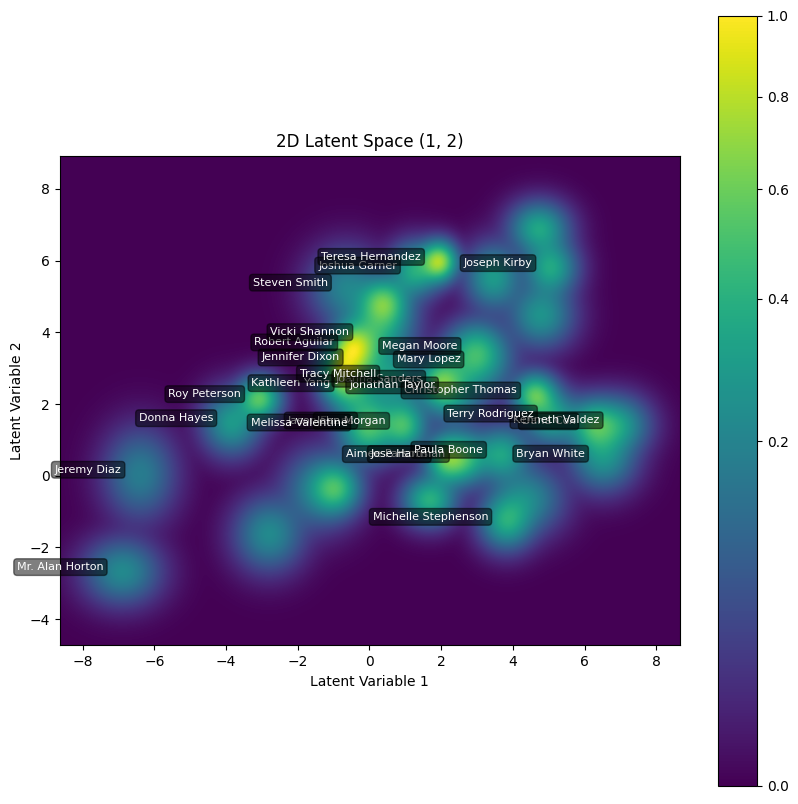

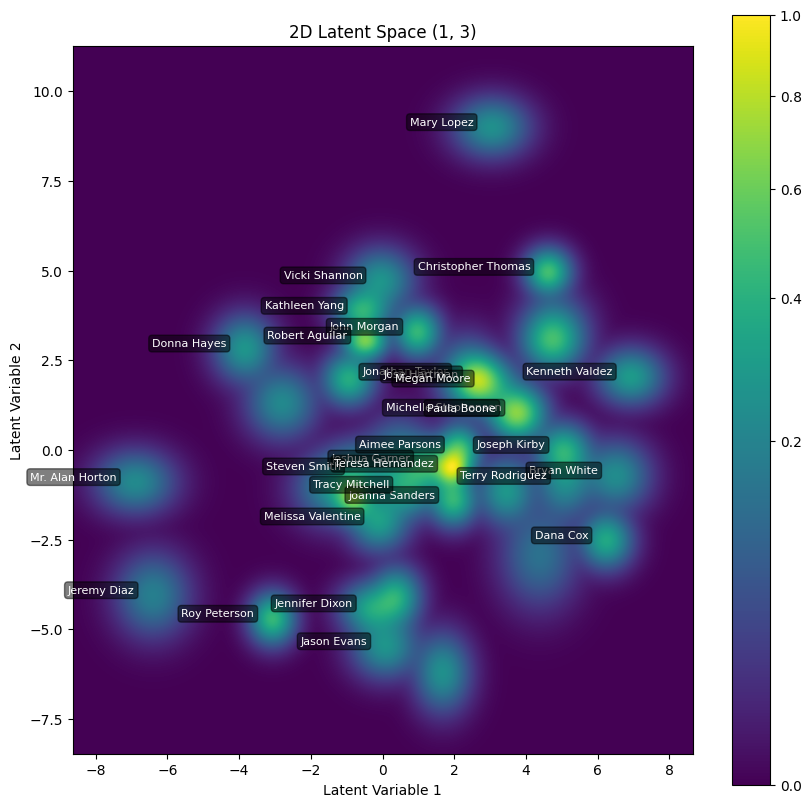

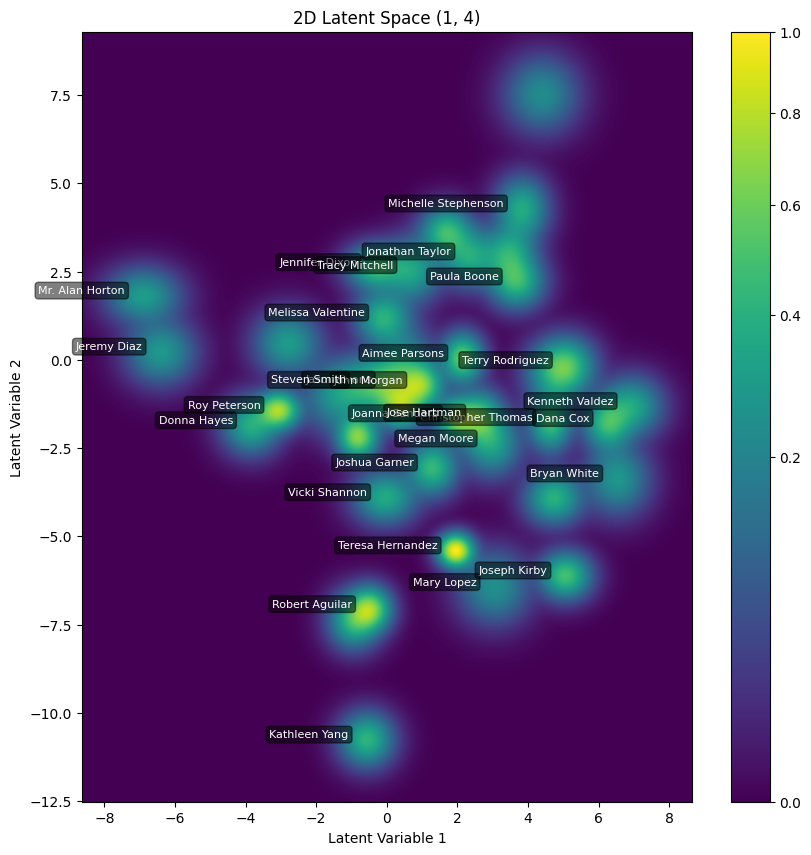

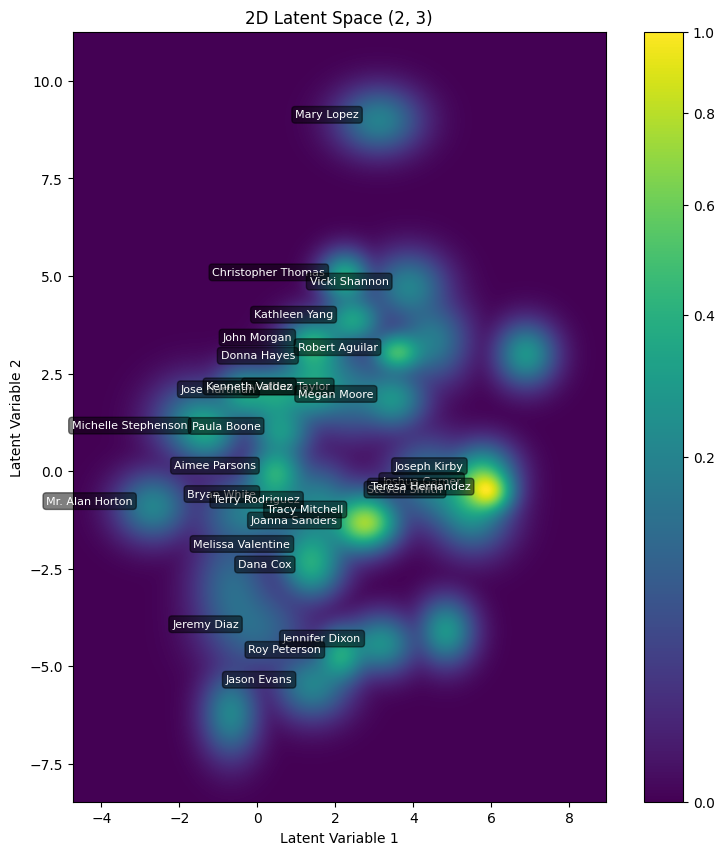

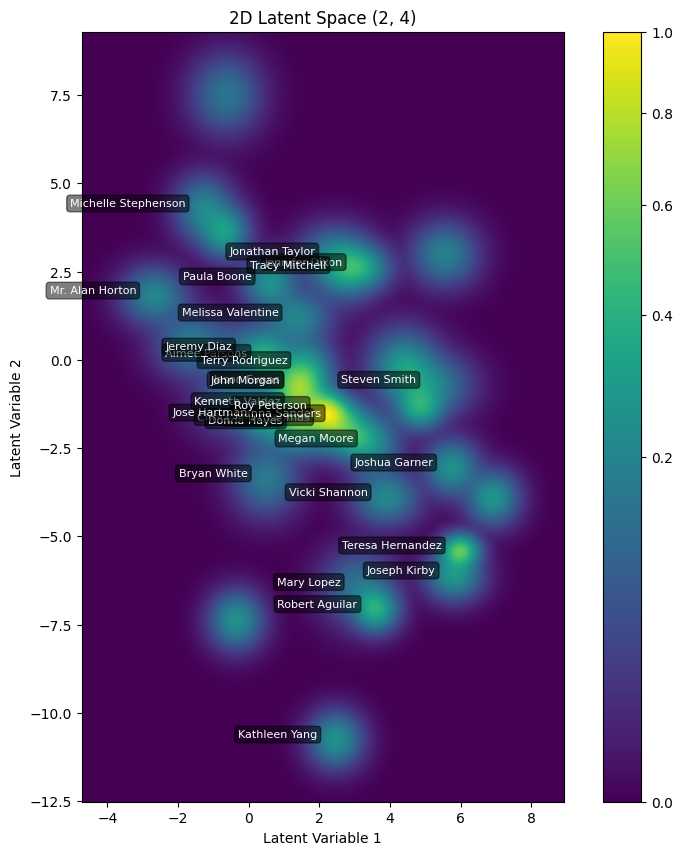

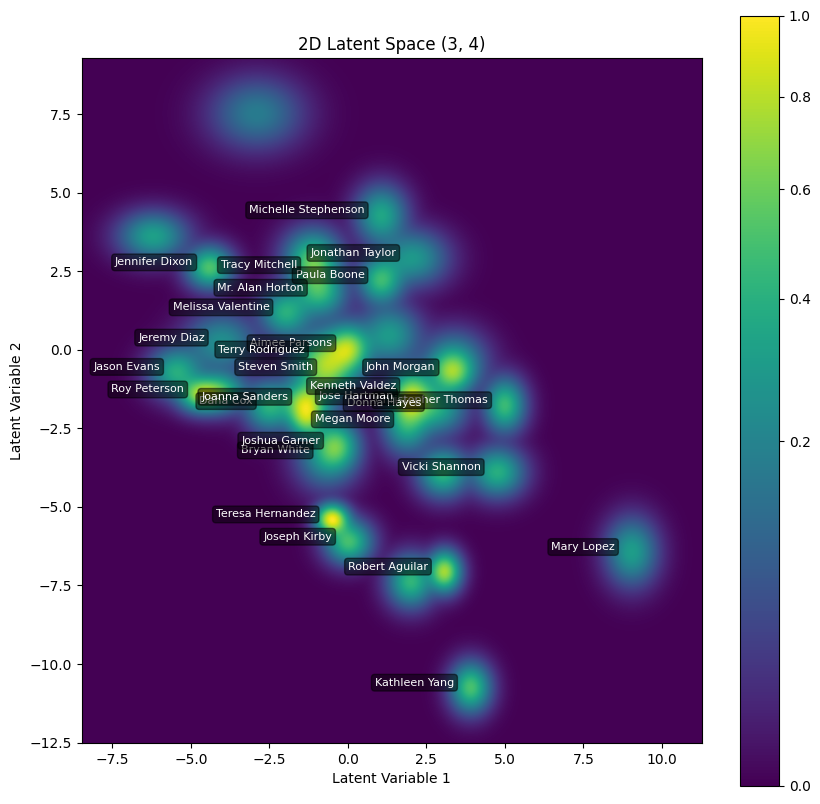

In [22]:
for i in dim1:
    for j in dim2:
        if i >= j:
            continue
        plotting.plot_multivariate_gaussian_image_with_labels(mu[:, [i, j]], std[:, [i, j]], user_names, title=f"2D Latent Space ({i}, {j})")